- Lektion 4 - Scikit-learn API (Del 1)
- Assignment: Classification and regression with a common API

Instructions:
1. Use scikit-learn estimators and the .fit/.predict pattern
2. Compare models on the same dataset
3. Add short comments explaining results

# Task 1: Dataset and split
- TODO: Load a dataset (iris, breast_cancer, or diabetes)
- TODO: Create train/test split with a fixed random_state

In [68]:
from sklearn.datasets import load_iris, load_diabetes

data = load_iris(as_frame=True)

X = data.data
y = data.target
target_names = data.target_names

In [69]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

In [70]:
print("X_train shape:", X_train.shape, "- X_test shape:", X_test.shape)

X_train shape: (100, 4) - X_test shape: (50, 4)


In [71]:
y_train.value_counts()

target
1    35
2    34
0    31
Name: count, dtype: int64

## EDA with plots


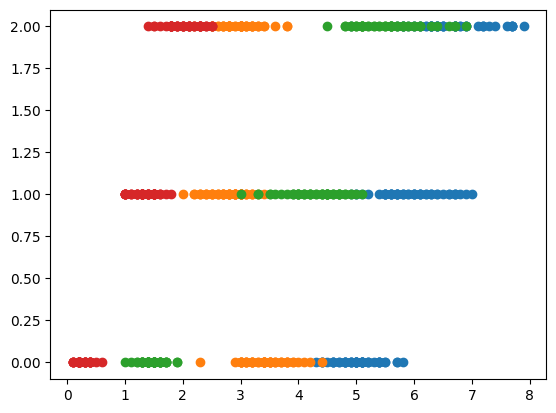

In [72]:
import matplotlib.pyplot as plt

plt.plot(X,y, 'o')

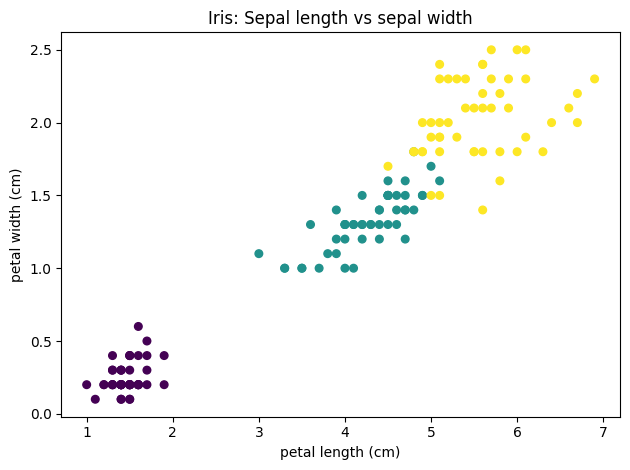

In [73]:
plt.scatter(X.iloc[:, 2], X.iloc[:, 3], c=y, cmap="viridis", s=30)
plt.title("Iris: Sepal length vs sepal width")
plt.xlabel(data.feature_names[2])
plt.ylabel(data.feature_names[3])
plt.tight_layout()
plt.show()

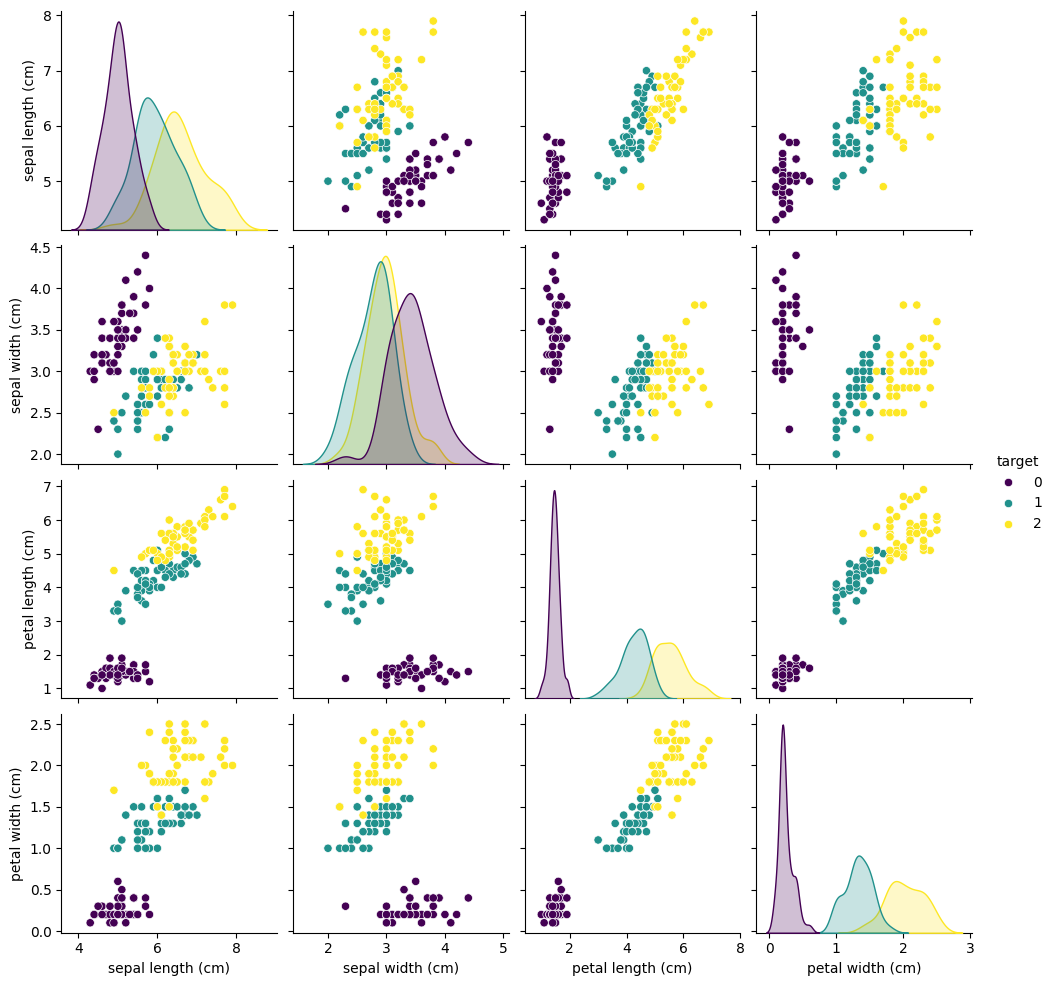

In [74]:
import seaborn as sns

sns.pairplot(data=data.frame, hue="target", vars=data.feature_names, palette="viridis")
plt.show()

# Task 2: Two models, same API
- TODO: Train LogisticRegression (classification) OR LinearRegression (regression)
- TODO: Train SVC (classification) OR Ridge (regression)
- TODO: Use .fit() and .predict() for both


In [75]:
from sklearn.linear_model import LogisticRegression

LogReg = LogisticRegression(max_iter=100)
LogReg.fit(X_train, y_train)

y_pred = LogReg.predict(X_test)

Our accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        15
           2       1.00      1.00      1.00        16

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50



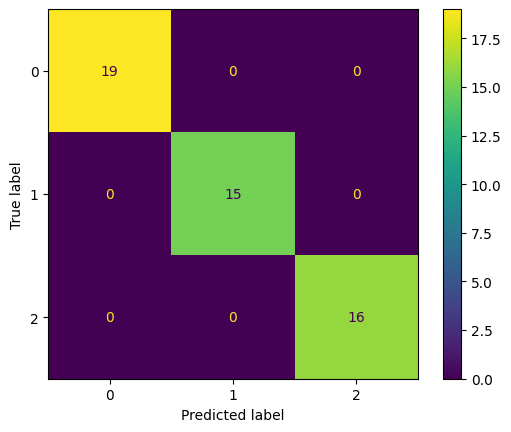

In [76]:
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

print("Our accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()

In [78]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="rbf", random_state=42))
])

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

Our accuracy: 0.98
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       0.94      1.00      0.97        15
           2       1.00      0.94      0.97        16

    accuracy                           0.98        50
   macro avg       0.98      0.98      0.98        50
weighted avg       0.98      0.98      0.98        50



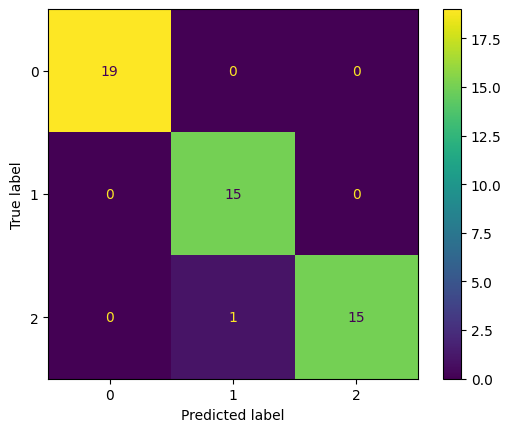

In [80]:
print("Our accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()

# Task 3: Metrics
- TODO: For classification: accuracy, precision, recall, f1
- TODO: For regression: MAE and R2
- TODO: Print a short comparison and comment on which model you prefer